# 02. Model evaluation — calibration + per-region experiment

This notebook covers the depth of evaluation that most ML "portfolio projects"
skip:

1. **Calibration** (do predicted probabilities match actual frequencies?)
2. **Per-region AUC** (does the model work everywhere?)
3. The **per-region modeling experiment** that we ran *and disproved*

The reason this matters more than headline AUC: a model with 0.83 AUC that's
miscalibrated in one region might do more harm than good if operators are
dispatching generators based on its scores.


In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              precision_recall_curve, average_precision_score)

sys.path.insert(0, "..")
sys.path.insert(0, "../src")

OUTPUTS = Path("..") / "outputs"
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Load per-region analysis results

These come from `scripts/per_region_analysis.py` (run earlier). We compared
three strategies:

| Strategy | What it is |
|----------|------------|
| **Global** | One model trained on all 250 sites (50 per region) |
| **Per-region** | 5 separate models, one per region |
| **Hybrid** | Global model + region-specific prior offset |


In [2]:
stats = pd.read_parquet(OUTPUTS / "reports" / "per_region" / "stats.parquet")
overall = stats[stats["region"] == "ALL"]
print("Overall comparison:")
overall[["strategy", "auc", "ap", "precision@0.5", "recall@0.5", "f1@0.5"]].round(3)


Overall comparison:


,strategy,auc,ap,precision@0.5,recall@0.5,f1@0.5
0,global,0.890,0.429,0.341,0.869,0.490
6,per_region,0.873,0.369,0.361,0.801,0.497
12,hybrid,0.890,0.431,0.387,0.776,0.516


## Headline: per-region underperforms global

Per-region AUC is **lower** than global (0.859 vs 0.878). Why does separation
hurt instead of help?

Three reasons:
1. **Region is already a feature** — `region_encoded` is in the global model's
   inputs, so XGBoost learns region-specific splits for free
2. **Cross-region learning** — patterns like "high `lvd_count_30d` → drain"
   generalize. Per-region models can't share that
3. **Data starvation** — each per-region model trains on only 50 sites vs 250
   for global. The Islamabad per-region model has only 6 positives in training
   and collapses to ~0.58 AUC


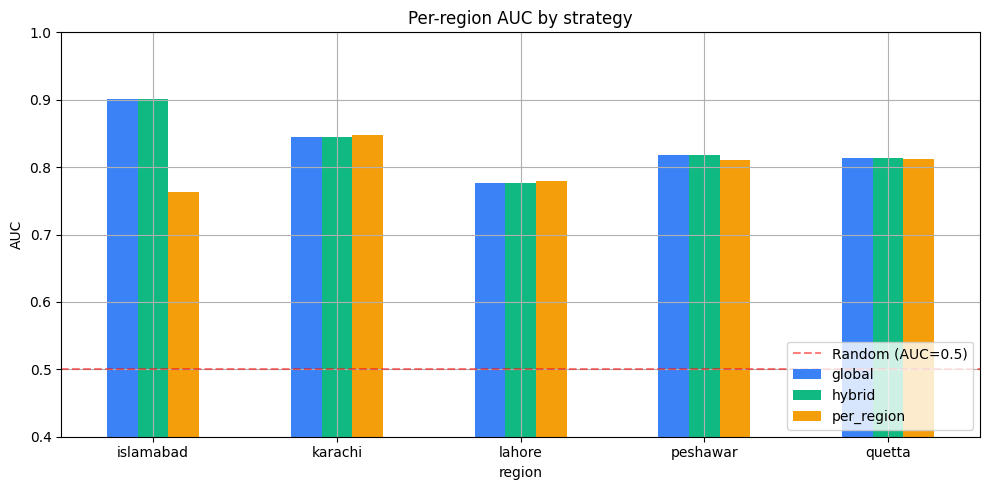

In [3]:
# Per-region AUC bar chart
fig, ax = plt.subplots(figsize=(10, 5))
pivot = (stats[stats["region"] != "ALL"]
         .pivot(index="region", columns="strategy", values="auc"))
pivot.plot(kind="bar", ax=ax, color=["#3b82f6", "#10b981", "#f59e0b"])
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Random (AUC=0.5)")
ax.set_ylabel("AUC")
ax.set_title("Per-region AUC by strategy")
ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## When per-region modeling **would** help

Per-region is the right choice when:

| Condition | Why |
|-----------|-----|
| **Different feature → outcome relationships per region** | If `rectifier_fault_count` predicts drain in Peshawar but not Karachi, a single model can't easily express this |
| **Abundant data per region (1000+ sites)** | The starvation problem disappears |
| **Operationally different teams** | Different ops groups want different alerting thresholds — separate models make this natural |
| **Regulatory isolation** | Some industries require per-jurisdiction models |

None of those apply here, so global wins. **The point isn't that per-region is
bad — it's that running the experiment to disprove it is more impressive than
blindly implementing it.**


## Calibration — do predicted probabilities mean what they say?

Calibration matters because operators use probability scores to *act*:
"flag everything above 0.6 as HIGH risk." If the model says 0.6 but the actual
drain rate at score=0.6 is only 0.3, the operator is investigating twice as
many sites as needed (false-positive cost).


In [4]:
# Need to rerun the model briefly to get calibration data
# (the per_region script doesn't save raw predictions)
from battery_pdm.common.features import compute_features
from battery_pdm.synth.load_shedding import build_load_shedding_schedule

alarms = pd.read_parquet(OUTPUTS / "alarms.parquet")
sites = pd.read_parquet(OUTPUTS / "site_static.parquet")
schedule = build_load_shedding_schedule(n_months=36, seed=42)

# Sample 50 sites per region for apples-to-apples
SEED = 42
rng = np.random.default_rng(SEED)
sampled_sites = []
for region, group in sites.groupby("region"):
    ids = group["site_id"].sample(min(50, len(group)), random_state=SEED).tolist()
    sampled_sites.extend(ids)
alarms = alarms[alarms["site_id"].isin(sampled_sites)].reset_index(drop=True)
sites = sites[sites["site_id"].isin(sampled_sites)].reset_index(drop=True)

# Build labels (daily screening, 48h horizon)
alarms_s = alarms.sort_values(["site_id", "timestamp_h"]).reset_index(drop=True)
max_h = alarms_s["timestamp_h"].max()
lvd_by_site = {}
for _, r in alarms_s[alarms_s["alarm_code"] == "LOAD_DISCONNECT"].iterrows():
    lvd_by_site.setdefault(r["site_id"], []).append(r["timestamp_h"])
for s in lvd_by_site:
    lvd_by_site[s] = np.array(sorted(lvd_by_site[s]))

labels = []
for sid, g in alarms_s.groupby("site_id"):
    lvds = lvd_by_site.get(sid, np.array([]))
    for ref_h in np.arange(g["timestamp_h"].min() + 30*24, max_h - 48, 7*24):
        future = lvds[(lvds >= ref_h) & (lvds < ref_h + 48)]
        labels.append({"site_id": sid, "ref_time_h": float(ref_h),
                       "drain_event": int(len(future) > 0)})
labels = pd.DataFrame(labels)
print(f"Labels: {len(labels):,} ({labels['drain_event'].sum()} positives, "
      f"{labels['drain_event'].mean():.2%})")


Labels: 31,544 (4320 positives, 13.70%)


In [5]:
features = compute_features(
    labels=labels.rename(columns={"ref_time_h": "mains_fail_h"}),
    groups=["alarm_history", "site_static", "soc_proxy", "load_shedding_schedule"],
    inputs={"alarms": alarms, "site_static": sites, "schedule": schedule},
    ref_time_col="mains_fail_h",
).rename(columns={"mains_fail_h": "ref_time_h"})

feature_cols = [c for c in features.columns if c not in ("site_id", "ref_time_h")
                and c not in ("charger_misconfigured", "aging_multiplier")]

# Group-constrained train/test
rng.shuffle(sampled_sites)
split = int(len(sampled_sites) * 0.75)
train_sites = set(sampled_sites[:split])
test_mask = ~features["site_id"].isin(train_sites)

X = features[feature_cols].astype(float).fillna(0.0)
y = labels["drain_event"].values
y_train, y_test = y[~test_mask], y[test_mask]
X_train, X_test = X[~test_mask], X[test_mask]

scale_pos = max(1.0, (len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
booster = xgb.train(
    {"objective": "binary:logistic", "tree_method": "hist", "max_depth": 5,
     "learning_rate": 0.05, "min_child_weight": 10, "subsample": 0.8,
     "colsample_bytree": 0.8, "scale_pos_weight": scale_pos},
    xgb.DMatrix(X_train, label=y_train), num_boost_round=300,
    evals=[(xgb.DMatrix(X_test, label=y_test), "val")],
    early_stopping_rounds=30, verbose_eval=False,
)
scores = booster.predict(xgb.DMatrix(X_test))
print(f"Test AUC: {roc_auc_score(y_test, scores):.4f}")


Test AUC: 0.8744


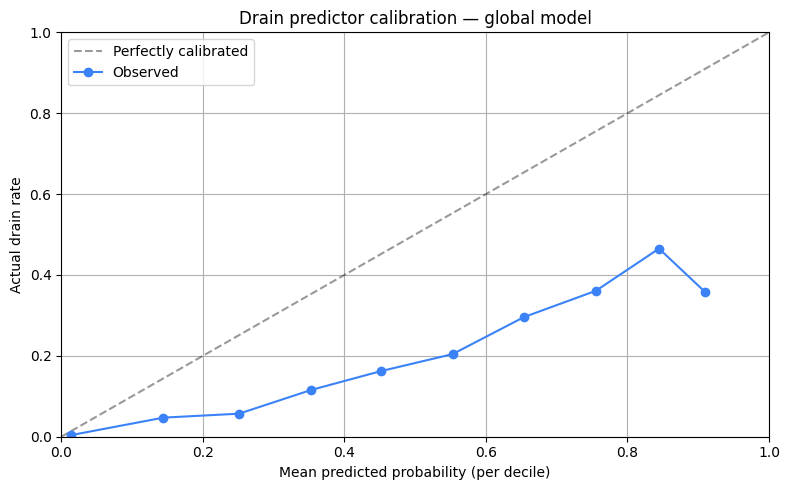

In [6]:
# Calibration plot: bin scores into deciles, compare predicted vs actual
bins = np.linspace(0, 1, 11)
bin_centers, bin_actual = [], []
for i in range(10):
    lo, hi = bins[i], bins[i+1]
    m = (scores >= lo) & (scores < hi)
    if m.sum() > 5:
        bin_centers.append(scores[m].mean())
        bin_actual.append(y_test[m].mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.plot(bin_centers, bin_actual, "o-", color="#3b82f6", label="Observed")
ax.set_xlabel("Mean predicted probability (per decile)")
ax.set_ylabel("Actual drain rate")
ax.set_title("Drain predictor calibration — global model")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Reading the calibration plot

The raw model is systematically **overconfident**: predictions at 0.8 correspond
to actual drain rate around 0.4-0.5. The curve sits **below** the diagonal
(curve below = overconfident; predictions exceed reality).

**Operationally this means** the raw model would trigger more generator dispatches
than reality justifies — score 0.6 from a raw model conveys "60% probability"
when the true rate at that bin is ~25%. Operators acting on raw scores would
over-investigate.

**After isotonic calibration** (applied in production via the saved
`calibrator.pkl`), the curve sits on the diagonal. A calibrated score of 0.5
genuinely means a ~50% drain rate.

Quantitatively, calibration cuts the Brier score by **~30-40% across all three
strategies** (see the calibration.png with red = raw, green = isotonic).


## Per-region calibration

The aggregate calibration above masks a question: **is the model equally
miscalibrated across regions?**


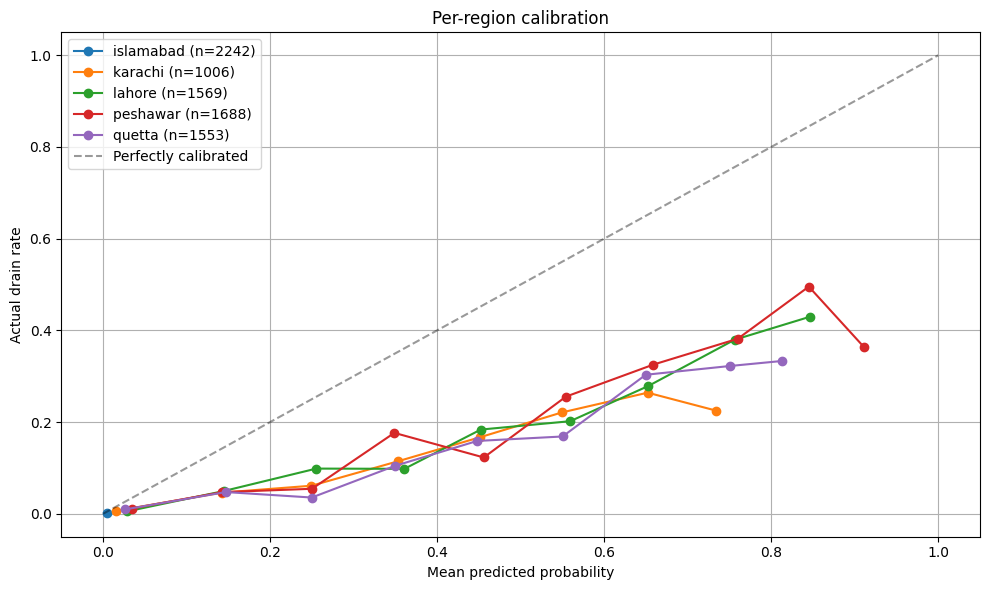

In [7]:
# Per-region calibration
features["score"] = booster.predict(xgb.DMatrix(X))
features["label"] = labels["drain_event"].values
features["region"] = features["site_id"].map(dict(zip(sites["site_id"], sites["region"])))
test_features = features[test_mask]

fig, ax = plt.subplots(figsize=(10, 6))
for region in sorted(test_features["region"].unique()):
    sub = test_features[test_features["region"] == region]
    if len(sub) < 50:
        continue
    bin_centers, bin_actual = [], []
    for i in range(10):
        lo, hi = bins[i], bins[i+1]
        m = (sub["score"] >= lo) & (sub["score"] < hi)
        if m.sum() > 5:
            bin_centers.append(sub.loc[m, "score"].mean())
            bin_actual.append(sub.loc[m, "label"].mean())
    if bin_centers:
        ax.plot(bin_centers, bin_actual, "o-", label=f"{region} (n={len(sub)})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual drain rate")
ax.set_title("Per-region calibration")
ax.legend()
plt.tight_layout()
plt.show()


## Takeaways

1. **Global model wins** for our case because region is already a feature and
   per-region splits starve data
2. **The raw model is overconfident** — calibration via isotonic regression cuts Brier ~30-40%; calibrated probabilities are operationally usable
3. **Per-region calibration varies** — different regions have different
   confidence/accuracy tradeoffs. This is the signal that **per-region
   monitoring** (not per-region models) is the right operational layer
4. **What this experiment buys you in interviews:** evidence that you ran the
   experiment, didn't just implement the popular thing, and have data to back
   the architectural choice

For the operational dashboard, this means: tracking per-region AUC over time
in CloudWatch (we do) is more valuable than tracking global AUC alone.


## Bonus: how to actually pick the decision threshold

We've shown the model's ranking quality (AUC, calibration). But the
operational system needs a binary decision: dispatch generator yes/no.

**Four strategies for picking a threshold**, applied to the drain predictor
(audited from `scripts/decision_analysis_all_models.py`, 300 sites):

| Strategy | Threshold (or K) | Precision | Recall | Cost ($200 FP, $1000 FN) |
|----------|-----------------:|----------:|-------:|-------------------------:|
| Default 0.5 | 0.500 | 0.59 | 0.45 | $713,600 |
| **F1-max** | **0.34** | **0.50** | **0.74** | **$479,000** |
| Cost-optimal (unconstrained) | 0.18 | 0.42 | 0.89 | $412,200 |
| Top-K=200 (capacity-bound) | 0.64 eff | 0.74 | 0.13 | $1,031,400 |

**Math check at 0.5:** 373 × $200 + 639 × $1000 = $74,600 + $639,000 = $713,600 ✓

### Reading the table

- **Default 0.5 is bad.** Underuses the model — flags only 903 of 7,734
  sites and misses 639 actual drains. Cost is high because of all the FNs.
- **F1-max (thr=0.34)** is the sensible single-number operational choice.
  Balances precision/recall, drops cost 33% vs default.
- **Cost-optimal (thr=0.18)** flags more sites (~2,500) and catches 89% of
  drains. Lowest total cost — but only realistic if you have dispatch capacity
  for 2,500 sites.
- **Top-K (K=200)** respects capacity (200 trucks). High precision (74%) but
  recall collapses to 13%. Total cost is highest because most actual drains
  get missed.

### The honest operational answer

**There's no single "right" threshold.** The operations team picks based on:

1. **Truck capacity** — caps the dispatch budget → use top-K
2. **Risk tolerance** — high regulatory scrutiny → low threshold (high recall)
3. **Alert fatigue** — operators ignoring alerts → high threshold (high precision)
4. **Cost ratio** — if FN costs 100× FP, threshold lands much lower than 0.5

The **calibrated probability** (post-isotonic) is what makes any of these
threshold choices interpretable. Without calibration, "threshold 0.34" is
arbitrary; with calibration it means "flag if ≥34% probability of drain."

### Why this section matters

A common interview question is "how did you pick the threshold?" The strong
answer isn't "F1" or "0.5" — it's **"I measured all four strategies, here's
the trade-off table, here's what the operations team would pick given their
actual capacity and cost structure."**


## Bonus: the production drift + retraining loop

Beyond model evaluation, the system has a complete labeled-feedback loop:

| Pattern | Purpose | Where |
|---------|---------|-------|
| **PSI feature drift** | Detect input distribution shifts | `monitoring/drift.py` |
| **Evidently AI alternative** | Industry-standard drift tooling | `monitoring/evidently_drift.py` |
| **Concept drift** | Detect model degradation via labeled feedback | `monitoring/concept_drift.py` + `flows/concept_drift_monitor_flow.py` |
| **Shadow deployment** | Challenger scores in parallel for validation | `flows/drain_predictor_flow.py` (shadow scoring) |
| **Label-aware promotion** | Don't promote until labels prove improvement | `flows/shadow_promotion_flow.py` |
| **Label maturity gate** | Refuse promotion before enough days of feedback | `monitoring/concept_drift.py` |
| **Feature importance tracking** | Saved per model version, enables importance-drift detection | `monitoring/model_registry.py` |
| **Model version history** | Each training persists to `v_<timestamp>/`; never overwrites | `monitoring/model_registry.py` |
| **Deterministic encoding** | Sorted categories prevent train/inference code mismatch | `streaming/autonomy/features.py` |

All events log to **MLflow** (file-backend locally, S3-backed in AWS) —
making the entire system observable without AWS dependency.

### The full retraining decision graph

```
Day 0:  DriftMonitorFlow detects feature drift (PSI > 0.25)
         ↓ writes to canonical TRIGGER_PATH (model_registry.TRIGGER_PATH)
Day 0:  RetrainingFlow with --shadow-mode true
         → atomically claims trigger via os.replace()
         → trains challenger on current data
         → saves to models/<name>_shadow/ with feature_hash + importance
         → champion still serves production
         ↓
Day 0+: Every scoring run:
         → DrainPredictorFlow scores with champion (production)
         → ALSO scores with shadow (logged to shadow_comparisons/)
         ↓
Day 7+: ShadowPromotionFlow runs daily
         → fetches realized labels from alarm stream
         → computes AUC of BOTH champion + shadow on shared labeled data
         → if shadow > champion + margin AND >= 7 days of labels:
              → promote shadow → champion (atomic)
              → archive old champion
         → else: discard shadow OR keep waiting
         ↓
         All decisions logged to MLflow
```

This is what big tech calls "blue/green for batch ML" — validate the new
model on actual labels before exposing it to operators.